<h2 style="text-align: center;">Identifikasi Kondisi Kantuk Pengemudi Menggunakan MobileNetV2 dan XGBoost pada Driver Drowsiness Dataset</h2>

**Masalah.** Kondisi kantuk pengemudi dapat memengaruhi kewaspadaan dan keselamatan berkendara. Karakteristik visual wajah (kondisi mata, ekspresi wajah) dapat dimanfaatkan untuk mengidentifikasi kondisi pengemudi (*Drowsy* vs *Non-Drowsy*).

**Tujuan.**
1. Mengembangkan metode identifikasi kondisi kantuk pengemudi berdasarkan karakteristik visual citra wajah.
2. Menggunakan **MobileNetV2** sebagai ekstraktor fitur visual.
3. Menggunakan **XGBoost** sebagai model pengambilan keputusan berdasarkan fitur dari MobileNetV2.
4. Mengevaluasi kemampuan kombinasi MobileNetV2–XGBoost dibandingkan pendekatan end-to-end CNN.

**Desain Eksperimen.**

| Eksperimen | Metode | Peran |
|---|---|---|
| Baseline | MobileNetV2 + Softmax | CNN end-to-end (fine-tuning) |
| Usulan | MobileNetV2 (frozen, feature extractor) + XGBoost | Pemisahan ekstraksi fitur & pengambilan keputusan |
| Pembanding | ResNet50V2 + Softmax | CNN end-to-end lain sebagai pembanding arsitektur |

Ketiganya dievaluasi dengan metrik yang sama: **Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Training Time, Inference Time.**


# ⚠️ PENTING: PASTIKAN ACCELERATOR GPU AKTIF DI KAGGLE!
Notebook ini sudah disesuaikan untuk **Kaggle Notebook**, memakai dataset
[Driver Drowsiness Dataset (DDD)](https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd)
yang sudah di-*attach* langsung (tidak perlu Google Drive / upload manual).

**Sebelum Run All:**
1. Klik **Add Data** (panel kanan) dan tambahkan dataset *Driver Drowsiness Dataset (DDD)* oleh `ismailnasri20`, jika belum ada.
2. Di panel kanan, buka **Settings -> Accelerator**, pilih **GPU T4 x2** (atau P100).
3. Pastikan **Internet** aktif di Settings (diperlukan untuk mengunduh bobot ImageNet MobileNetV2/ResNet50V2).
4. Jalankan semua sel (**Run All**).


# 🔗 Importing Libraries

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(3)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# XGBoost biasanya sudah tersedia di image Kaggle. Uncomment jika belum ada.
# !pip install xgboost -q
from xgboost import XGBClassifier

# Optimasi Kecepatan GPU (Mixed Precision)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


In [2]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


# 🔗 Konfigurasi
Path dataset dan hasil split disesuaikan untuk lingkungan **Kaggle Notebook**:
- Dataset dibaca langsung dari `/kaggle/input/...` (read-only, sudah tersedia otomatis lewat Add Data).
- Hasil split (train/test/val) ditulis ke `/kaggle/working/` (satu-satunya folder yang bisa ditulis di Kaggle).
- Tidak ada proses mount Google Drive maupun *staging copy* seperti versi Colab sebelumnya.


In [3]:
import os
from pathlib import Path

IMAGE_SIZE = (160, 160)
BATCH_SIZE = 64
SEED = 1337

# ============================================================
# Deteksi otomatis lokasi dataset di /kaggle/input
# (tidak hardcode nama slug persis, karena kadang berbeda)
# ============================================================
KAGGLE_INPUT_ROOT = "/kaggle/input"

def find_class_root(root):
    root = Path(root)
    if not root.is_dir():
        raise FileNotFoundError(
            f"Folder tidak ditemukan: {root}\n"
            "Pastikan dataset 'Driver Drowsiness Dataset (DDD)' (ismailnasri20) "
            "sudah ditambahkan lewat menu Add Data di Kaggle Notebook."
        )
    print("Isi /kaggle/input:", os.listdir(root))
    for dirpath, dirnames, _ in os.walk(root):
        lower_names = [d.lower() for d in dirnames]
        if any("drowsy" in name for name in lower_names):
            return Path(dirpath)
    raise FileNotFoundError(
        f"Tidak ditemukan subfolder kelas (mis. 'Drowsy') di bawah {root}.\n"
        "Jalankan `!find /kaggle/input -maxdepth 4` di sel terpisah untuk cek "
        "struktur folder aslinya, lalu sesuaikan logic pencarian di atas jika perlu."
    )

# Dataset asli (read-only), diambil langsung dari Kaggle Input
DATA_DIR = str(find_class_root(KAGGLE_INPUT_ROOT))
print("DATA_DIR terdeteksi:", DATA_DIR)

# Folder hasil split (satu-satunya lokasi yang writable di Kaggle)
SPLIT_DIR = "/kaggle/working/splitted_Data"

# ============================================================
# Konfigurasi paralelisasi data loading (untuk .fit()/.predict())
# ============================================================
WORKERS = max(2, (os.cpu_count() or 2))
USE_MULTIPROCESSING = True
MAX_QUEUE_SIZE = 20

print(f"WORKERS={WORKERS}, USE_MULTIPROCESSING={USE_MULTIPROCESSING}, MAX_QUEUE_SIZE={MAX_QUEUE_SIZE}")

Isi /kaggle/input: ['datasets']
DATA_DIR terdeteksi: /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)
WORKERS=4, USE_MULTIPROCESSING=True, MAX_QUEUE_SIZE=20


In [4]:
# ============================================================
# CATATAN: tahap "FAST DATA STAGING" (copy Google Drive -> local runtime)
# dari versi Colab TIDAK diperlukan lagi di Kaggle.
#
# /kaggle/input sudah berupa disk lokal read-only yang cepat diakses,
# jadi kita bisa langsung membaca DATA_DIR tanpa proses copy tambahan.
# Proses split di sel berikutnya akan langsung membaca dari DATA_DIR
# dan menulis hasilnya ke SPLIT_DIR (/kaggle/working).
# ============================================================
print("Melewati tahap staging - membaca dataset langsung dari:", DATA_DIR)


Melewati tahap staging - membaca dataset langsung dari: /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)


# 🔗 Dividing Data into (train, test, val) folders

In [5]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

# Pastikan folder dataset sumber ada
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_DIR}")

# Class = subfolder langsung di dalam DATA_DIR
class_dirs = sorted([
    p for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and not p.name.startswith('.')
])

if not class_dirs:
    raise RuntimeError(f"Tidak ditemukan folder kelas di {DATA_DIR}")

print(f"Ditemukan {len(class_dirs)} kelas:", [p.name for p in class_dirs])

# Hapus hasil split lama/parsial di /kaggle/working saja.
# Dataset asli di /kaggle/input tidak disentuh (read-only).
if os.path.exists(SPLIT_DIR):
    print(f"Menghapus hasil split lama/parsial: {SPLIT_DIR}")
    shutil.rmtree(SPLIT_DIR)

for split_name in ["train", "test", "val"]:
    for class_dir in class_dirs:
        (Path(SPLIT_DIR) / split_name / class_dir.name).mkdir(parents=True, exist_ok=True)

# Buat split per kelas agar proporsi tiap kelas tetap terjaga.
rng = np.random.RandomState(SEED)
total_created = {"train": 0, "test": 0, "val": 0}

for class_dir in class_dirs:
    files = sorted([
        p for p in class_dir.iterdir()
        if p.is_file() and not p.name.startswith('.')
    ])

    if not files:
        print(f"⚠️ Kelas kosong: {class_dir.name}")
        continue

    # Acak deterministik berdasarkan SEED.
    files = np.array(files, dtype=object)
    rng.shuffle(files)

    n = len(files)
    n_train = int(n * 0.80)
    n_test = int(n * 0.15)
    # Sisa masuk validation agar total tepat 100%.
    split_files = {
        "train": files[:n_train],
        "test": files[n_train:n_train + n_test],
        "val": files[n_train + n_test:]
    }

    for split_name, selected_files in split_files.items():
        target_dir = Path(SPLIT_DIR) / split_name / class_dir.name
        for src_file in selected_files:
            target = target_dir / src_file.name
            # Symlink (bukan copy fisik): karena DATA_DIR sudah berada di
            # /kaggle/input (disk lokal, read-only), tidak perlu duplikasi
            # ~41 ribu file ke /kaggle/working. Ini jauh lebih cepat dan
            # menghemat kuota disk /kaggle/working.
            try:
                if target.exists() or target.is_symlink():
                    target.unlink()
                os.symlink(src_file, target)
            except OSError:
                # Fallback ke copy fisik kalau symlink tidak didukung
                shutil.copy2(src_file, target)
            total_created[split_name] += 1

print("\n✅ Split selesai (file di-symlink ke SPLIT_DIR, fallback copy jika perlu).")
print(f"Train : {total_created['train']:,} file")
print(f"Test  : {total_created['test']:,} file")
print(f"Val   : {total_created['val']:,} file")
print(f"Total : {sum(total_created.values()):,} file")
print(f"\nFolder split: {SPLIT_DIR}")
print("Dataset asli di /kaggle/input tetap utuh (read-only, tidak disentuh).")


Ditemukan 2 kelas: ['Drowsy', 'Non Drowsy']

✅ Split selesai (file di-symlink ke SPLIT_DIR, fallback copy jika perlu).
Train : 33,434 file
Test  : 6,268 file
Val   : 2,091 file
Total : 41,793 file

Folder split: /kaggle/working/splitted_Data
Dataset asli di /kaggle/input tetap utuh (read-only, tidak disentuh).


In [6]:
for split_name in ["train", "test", "val"]:
    print(f"\n{split_name.upper()}")
    for class_dir in sorted((Path(SPLIT_DIR) / split_name).iterdir()):
        if class_dir.is_dir():
            count = sum(1 for p in class_dir.iterdir() if p.is_file())
            print(f"  {class_dir.name}: {count:,}")



TRAIN
  Drowsy: 17,878
  Non Drowsy: 15,556

TEST
  Drowsy: 3,352
  Non Drowsy: 2,916

VAL
  Drowsy: 1,118
  Non Drowsy: 973


# 🔗 Reading Data (train, test, val)

In [7]:
train_dir = os.path.join(SPLIT_DIR, "train")
test_dir  = os.path.join(SPLIT_DIR, "test")
val_dir   = os.path.join(SPLIT_DIR, "val")


### 🔖 Generator untuk training (shuffle=True)
Digunakan saat memanggil `.fit()` pada model CNN (Baseline & Pembanding).

In [8]:
# ============================================================
# GPU CHECK + MIXED PRECISION
# ============================================================
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPU terdeteksi:", gpus)

if gpus:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision:", mixed_precision.global_policy())
    except Exception as e:
        print("Mixed precision tidak diaktifkan:", e)
else:
    print("PERINGATAN: GPU tidak terdeteksi. Aktifkan GPU pada runtime Colab.")


GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">


In [9]:
# Data augmentation khusus untuk generator training agar model tidak mudah overfit
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_batches = train_datagen.flow_from_directory(
    train_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True, seed=SEED
)

val_batches = val_datagen.flow_from_directory(
    val_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True, seed=SEED
)

test_batches = test_datagen.flow_from_directory(
    test_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True, seed=SEED
)


Found 33434 images belonging to 2 classes.
Found 2091 images belonging to 2 classes.
Found 6268 images belonging to 2 classes.


### 🔖 Generator untuk evaluasi & ekstraksi fitur (shuffle=False)
Dipakai untuk `.predict()` dan untuk ekstraksi fitur MobileNetV2 (Usulan), supaya urutan prediksi
selalu selaras dengan urutan label (`generator.classes`).

In [10]:
train_eval_batches = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

val_eval_batches = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

test_eval_batches = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

CLASS_INDICES = train_batches.class_indices
CLASS_NAMES = list(CLASS_INDICES.keys())
print("Class indices:", CLASS_INDICES)


Found 33434 images belonging to 2 classes.
Found 2091 images belonging to 2 classes.
Found 6268 images belonging to 2 classes.
Class indices: {'Drowsy': 0, 'Non Drowsy': 1}


# 🔗 Verifikasi Data

In [11]:
train_counts = Counter(train_batches.classes)
val_counts   = Counter(val_batches.classes)
test_counts  = Counter(test_batches.classes)

print("Train :", train_counts)
print("Val   :", val_counts)
print("Test  :", test_counts)


Train : Counter({np.int32(0): 17878, np.int32(1): 15556})
Val   : Counter({np.int32(0): 1118, np.int32(1): 973})
Test  : Counter({np.int32(0): 3352, np.int32(1): 2916})


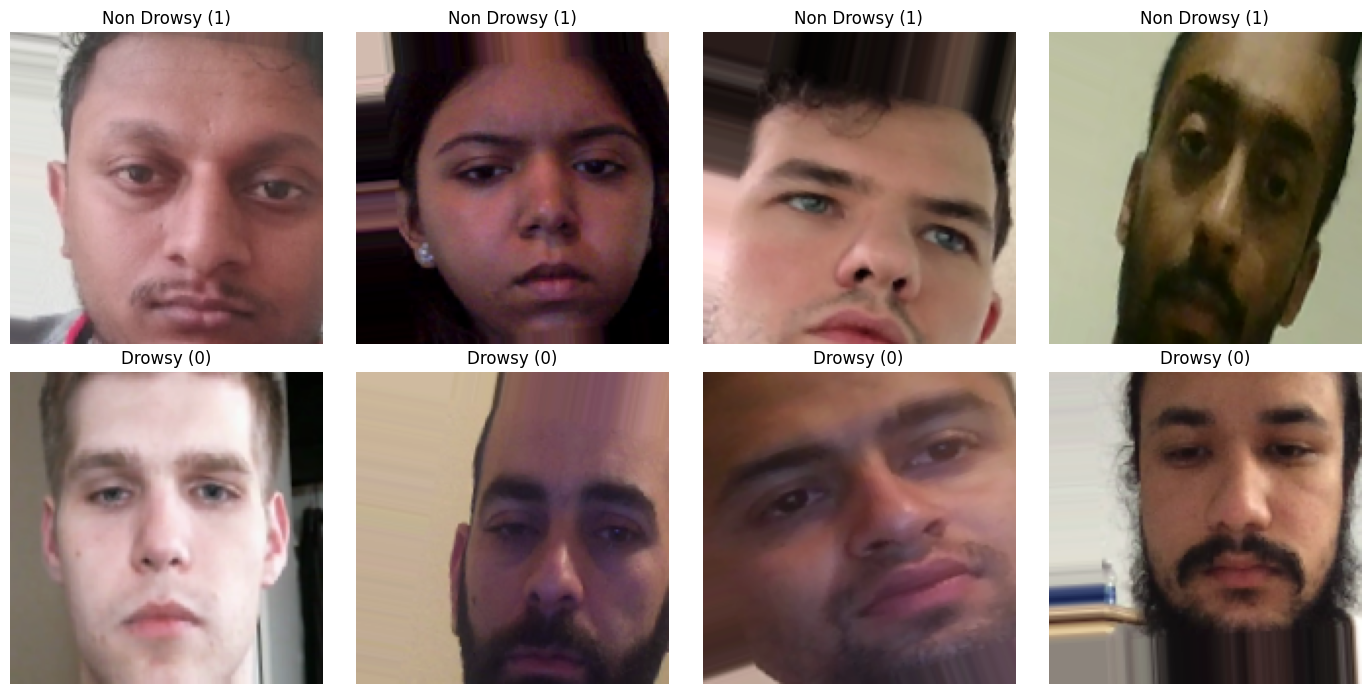

In [12]:
images, labels = next(train_batches)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(f"{CLASS_NAMES[int(labels[i])]} ({int(labels[i])})")
    ax.axis('off')
plt.tight_layout()
plt.show()


# 🔗 Fungsi Bantu Evaluasi
Fungsi ini dipakai berulang di ketiga eksperimen agar cara menghitung metrik konsisten dan bisa dibandingkan secara adil.

In [13]:
results_summary = {}

def evaluate_and_record(exp_name, y_true, y_pred, train_time, inference_time, n_test_samples):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)

    results_summary[exp_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Training Time (s)": train_time,
        "Inference Time (s)": inference_time,
        "Inference Time per Image (ms)": (inference_time / n_test_samples) * 1000,
        "Confusion Matrix": cm,
    }

    print(f"=== {exp_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"Training time  : {train_time:.2f} s")
    print(f"Inference time : {inference_time:.2f} s ({(inference_time/n_test_samples)*1000:.2f} ms/image)")
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='bone',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {exp_name}')
    plt.show()

    return results_summary[exp_name]


# 🔗 Eksperimen 1 (Baseline): MobileNetV2 + Softmax
Pendekatan end-to-end: MobileNetV2 di-*fine-tune* langsung sebagai model klasifikasi (25 layer terakhir dibuka untuk training),
diikuti beberapa Dense layer dan Softmax. Ini adalah pendekatan yang paling umum dipakai pada literatur deteksi kantuk berbasis CNN.

In [14]:
base_model_a = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
)

for layer in base_model_a.layers[:-25]:
    layer.trainable = False

x = base_model_a.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
predictions_a = Dense(2, activation='softmax', dtype='float32')(x)

model_baseline = Model(inputs=base_model_a.input, outputs=predictions_a)
model_baseline.compile(optimizer=Adam(0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_baseline.summary()


I0000 00:00:1789718062.234608      25 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789718062.237401      25 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 4,095,554 (15.62 MB)

 Trainable params: 3,199,490 (12.21 MB)

 Non-trainable params: 896,064 (3.42 MB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

start_train = time.time()
history_baseline = model_baseline.fit(
    train_batches,
    epochs=20, # Ditingkatkan karena sudah ada early stopping
    validation_data=val_batches,
    callbacks=[early_stopping_cb]
)
train_time_baseline = time.time() - start_train
print(f"Training time: {train_time_baseline:.2f} s")

Epoch 1/20


2026-09-18 07:54:55.657119: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 07:54:55.795755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789718102.353926     117 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


523/523 ━━━━━━━━━━━━━━━━━━━━ 507s 883ms/step - accuracy: 0.9742 - loss: 0.0651 - val_accuracy: 0.7150 - val_loss: 1.3684
Epoch 2/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 291s 556ms/step - accuracy: 0.9964 - loss: 0.0099 - val_accuracy: 0.9680 - val_loss: 0.1285
Epoch 3/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 286s 546ms/step - accuracy: 0.9975 - loss: 0.0078 - val_accuracy: 0.9833 - val_loss: 0.0610
Epoch 4/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 299s 571ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9986 - val_loss: 0.0057
Epoch 5/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 304s 582ms/step - accuracy: 0.9985 - loss: 0.0048 - val_accuracy: 0.9990 - val_loss: 0.0025
Epoch 6/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 294s 562ms/step - accuracy: 0.9990 - loss: 0.0030 - val_accuracy: 0.9938 - val_loss: 0.0226
Epoch 7/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 294s 562ms/step - accuracy: 0.9982 - loss: 0.0053 - val_accuracy: 0.9971 - val_loss: 0.0088
Epoch 8/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 292s 559ms/step - accuracy: 0.9990 - loss: 0.00

98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 722ms/step
=== Baseline (MobileNetV2 + Softmax) ===
Accuracy : 0.9997
Precision: 1.0000
Recall   : 0.9993
F1-Score : 0.9997
Training time  : 2568.46 s
Inference time : 84.33 s (13.45 ms/image)

              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      3352
  Non Drowsy       1.00      1.00      1.00      2916

    accuracy                           1.00      6268
   macro avg       1.00      1.00      1.00      6268
weighted avg       1.00      1.00      1.00      6268



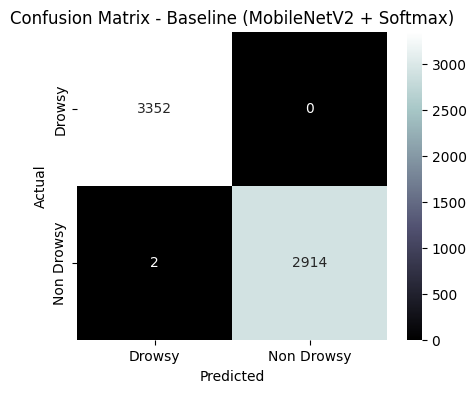

{'Accuracy': 0.9996809189534142,
 'Precision': 1.0,
 'Recall': 0.9993141289437586,
 'F1-Score': 0.9996569468267581,
 'Training Time (s)': 2568.4618265628815,
 'Inference Time (s)': 84.32988691329956,
 'Inference Time per Image (ms)': 13.454034287380274,
 'Confusion Matrix': array([[3352,    0],
        [   2, 2914]])}

In [16]:
start_infer = time.time()
y_pred_proba_baseline = model_baseline.predict(
    test_eval_batches
)
inference_time_baseline = time.time() - start_infer

y_pred_baseline = np.argmax(y_pred_proba_baseline, axis=1)
y_true_baseline = test_eval_batches.classes

evaluate_and_record(
    "Baseline (MobileNetV2 + Softmax)",
    y_true_baseline, y_pred_baseline,
    train_time_baseline, inference_time_baseline,
    n_test_samples=test_eval_batches.samples,
)

# 🔗 Eksperimen 2 (Usulan): MobileNetV2 (Feature Extractor) + XGBoost
Berbeda dari Baseline, di sini MobileNetV2 **sepenuhnya dibekukan** (tidak di-*fine-tune*) dan hanya berperan sebagai
ekstraktor fitur visual. Output dari `GlobalAveragePooling2D` dijadikan *feature vector*, lalu **XGBoost** yang
berperan sebagai model pengambilan keputusan (Drowsy vs Non-Drowsy).

Alur: `DDD → Preprocessing → MobileNetV2 (frozen) → Global Average Pooling → Feature Vector → XGBoost → Drowsy/Non-Drowsy`

In [17]:
base_model_b = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    pooling='avg',   # langsung Global Average Pooling di output
)
base_model_b.trainable = False   # seluruh layer dibekukan, murni ekstraktor fitur

feature_extractor = base_model_b
feature_extractor.summary()


Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
def extract_features(generator, model):
    generator.reset()
    features = model.predict(
        generator,
        verbose=1
    )
    labels = generator.classes
    return features, labels

X_train_feat, y_train_feat = extract_features(train_eval_batches, feature_extractor)
X_val_feat,   y_val_feat   = extract_features(val_eval_batches,   feature_extractor)
X_test_feat,  y_test_feat  = extract_features(test_eval_batches,  feature_extractor)

print("Feature shapes:", X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)

523/523 ━━━━━━━━━━━━━━━━━━━━ 154s 269ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 595ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 34s 343ms/step
Feature shapes: (33434, 1280) (2091, 1280) (6268, 1280)


In [19]:
xgb_model = XGBClassifier(
    n_estimators=500,     # Ditingkatkan agar model lebih robust
    max_depth=7,          # Sedikit diperdalam untuk menangkap pola fitur kompleks
    learning_rate=0.05,   # Diperlambat agar konvergensi lebih stabil (meningkatkan akurasi)
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=SEED,
    early_stopping_rounds=15, # Menambahkan early stopping untuk xgboost
)

start_train = time.time()
xgb_model.fit(
    X_train_feat, y_train_feat,
    eval_set=[(X_val_feat, y_val_feat)],
    verbose=100,
)
train_time_xgb = time.time() - start_train
print(f'Training time: {train_time_xgb:.2f} s')


[0]	validation_0-logloss:0.65339
[100]	validation_0-logloss:0.02863
[200]	validation_0-logloss:0.00887
[300]	validation_0-logloss:0.00727
[329]	validation_0-logloss:0.00715
Training time: 157.90 s


=== Usulan (MobileNetV2 + XGBoost) ===
Accuracy : 0.9997
Precision: 0.9997
Recall   : 0.9997
F1-Score : 0.9997
Training time  : 157.90 s
Inference time : 0.09 s (0.01 ms/image)

              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      3352
  Non Drowsy       1.00      1.00      1.00      2916

    accuracy                           1.00      6268
   macro avg       1.00      1.00      1.00      6268
weighted avg       1.00      1.00      1.00      6268



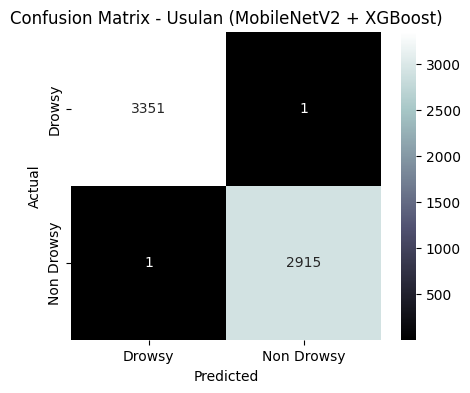

{'Accuracy': 0.9996809189534142,
 'Precision': 0.9996570644718793,
 'Recall': 0.9996570644718793,
 'F1-Score': 0.9996570644718793,
 'Training Time (s)': 157.89681458473206,
 'Inference Time (s)': 0.08709025382995605,
 'Inference Time per Image (ms)': 0.013894424669744106,
 'Confusion Matrix': array([[3351,    1],
        [   1, 2915]])}

In [20]:
start_infer = time.time()
y_pred_xgb = xgb_model.predict(X_test_feat)
inference_time_xgb = time.time() - start_infer

evaluate_and_record(
    "Usulan (MobileNetV2 + XGBoost)",
    y_test_feat, y_pred_xgb,
    train_time_xgb, inference_time_xgb,
    n_test_samples=len(y_test_feat),
)


# 🔗 Eksperimen 3 (Pembanding): ResNet50V2 + Softmax
Sebagai pembanding arsitektur CNN end-to-end lain (di luar MobileNetV2), dengan perlakuan training yang sama
seperti Baseline (fine-tuning, epoch, optimizer identik) agar perbandingan adil.

In [21]:
base_model_c = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
)

for layer in base_model_c.layers[:-25]:
    layer.trainable = False

x = base_model_c.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
predictions_c = Dense(2, activation='softmax', dtype='float32')(x)

model_resnet = Model(inputs=base_model_c.input, outputs=predictions_c)
model_resnet.compile(optimizer=Adam(0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_resnet.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 166, 166,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 80, 80,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 82, 82,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 40, 40,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 40, 40,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 40, 40,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 40, 40,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 40, 40,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 40, 40,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 42, 42,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 40, 40,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 40, 40,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 40, 40,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 40, 40,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 40, 40,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 40, 40,    │          0 │ conv2_block1_0_c

 Total params: 26,188,802 (99.90 MB)

 Trainable params: 11,557,378 (44.09 MB)

 Non-trainable params: 14,631,424 (55.81 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

start_train = time.time()
history_resnet = model_resnet.fit(
    train_batches,
    epochs=20, # Ditingkatkan karena sudah ada early stopping
    validation_data=val_batches,
    callbacks=[early_stopping_cb]
)
train_time_resnet = time.time() - start_train
print(f"Training time: {train_time_resnet:.2f} s")

Epoch 1/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 358s 642ms/step - accuracy: 0.9688 - loss: 0.0770 - val_accuracy: 0.9995 - val_loss: 0.0026
Epoch 2/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 311s 594ms/step - accuracy: 0.9960 - loss: 0.0128 - val_accuracy: 0.9990 - val_loss: 0.0025
Epoch 3/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 301s 576ms/step - accuracy: 0.9971 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 3.2656e-04
Epoch 4/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 298s 570ms/step - accuracy: 0.9974 - loss: 0.0080 - val_accuracy: 0.9990 - val_loss: 0.0043
Epoch 5/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 305s 583ms/step - accuracy: 0.9983 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 6.5036e-04
Epoch 6/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 308s 588ms/step - accuracy: 0.9989 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 4.7950e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Training time: 1881.49 s


98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 387ms/step
=== Pembanding (ResNet50V2 + Softmax) ===
Accuracy : 0.9994
Precision: 0.9986
Recall   : 1.0000
F1-Score : 0.9993
Training time  : 1881.49 s
Inference time : 43.90 s (7.00 ms/image)

              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      3352
  Non Drowsy       1.00      1.00      1.00      2916

    accuracy                           1.00      6268
   macro avg       1.00      1.00      1.00      6268
weighted avg       1.00      1.00      1.00      6268



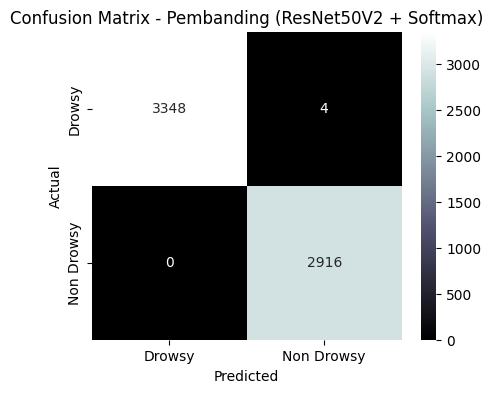

{'Accuracy': 0.9993618379068283,
 'Precision': 0.9986301369863013,
 'Recall': 1.0,
 'F1-Score': 0.9993145990404386,
 'Training Time (s)': 1881.491821050644,
 'Inference Time (s)': 43.89618110656738,
 'Inference Time per Image (ms)': 7.00321970430239,
 'Confusion Matrix': array([[3348,    4],
        [   0, 2916]])}

In [23]:
start_infer = time.time()
y_pred_proba_resnet = model_resnet.predict(
    test_eval_batches
)
inference_time_resnet = time.time() - start_infer

y_pred_resnet = np.argmax(y_pred_proba_resnet, axis=1)
y_true_resnet = test_eval_batches.classes

evaluate_and_record(
    "Pembanding (ResNet50V2 + Softmax)",
    y_true_resnet, y_pred_resnet,
    train_time_resnet, inference_time_resnet,
    n_test_samples=test_eval_batches.samples,
)

# 🔗 Perbandingan Ketiga Eksperimen
Tabel dan grafik ringkasan untuk membandingkan Baseline, Usulan, dan Pembanding pada metrik yang sama:
Accuracy, Precision, Recall, F1-Score, Training Time, dan Inference Time.

In [24]:
summary_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != "Confusion Matrix"}
    for name, metrics in results_summary.items()
}).T

summary_df = summary_df[["Accuracy", "Precision", "Recall", "F1-Score",
                          "Training Time (s)", "Inference Time (s)", "Inference Time per Image (ms)"]]
summary_df.round(4)


,Accuracy,Precision,Recall,F1-Score,Training Time (s),Inference Time (s),Inference Time per Image (ms)
Baseline (MobileNetV2 + Softmax),0.9997,1.0000,0.9993,0.9997,2568.4618,84.3299,13.4540
Usulan (MobileNetV2 + XGBoost),0.9997,0.9997,0.9997,0.9997,157.8968,0.0871,0.0139
Pembanding (ResNet50V2 + Softmax),0.9994,0.9986,1.0000,0.9993,1881.4918,43.8962,7.0032


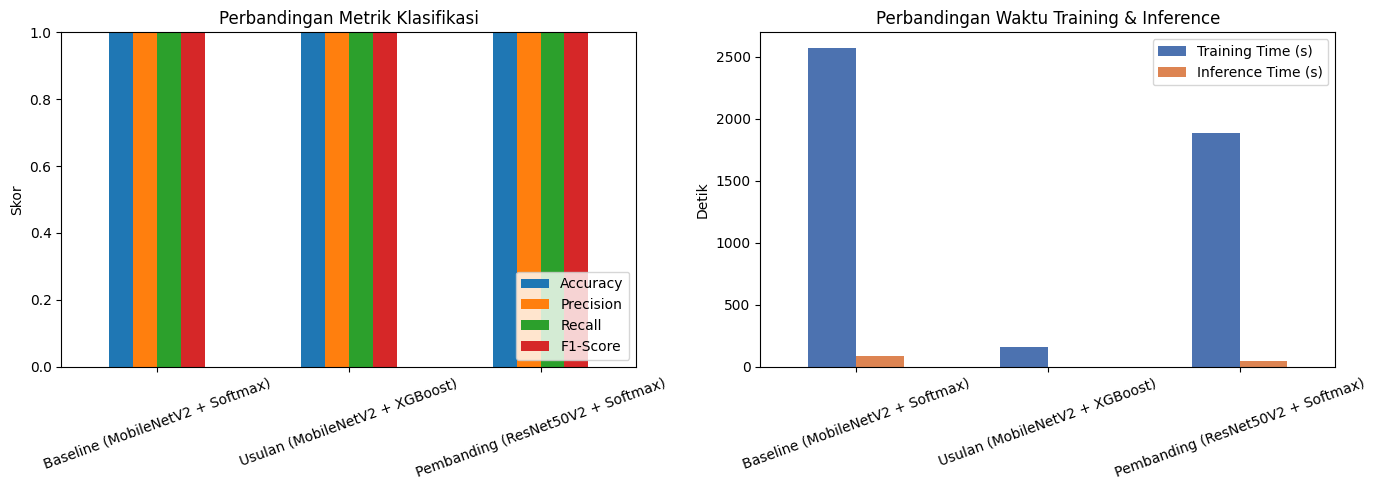

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
summary_df[metrics_to_plot].plot(kind='bar', ax=axes[0])
axes[0].set_title("Perbandingan Metrik Klasifikasi")
axes[0].set_ylabel("Skor")
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=20)

summary_df[["Training Time (s)", "Inference Time (s)"]].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title("Perbandingan Waktu Training & Inference")
axes[1].set_ylabel("Detik")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


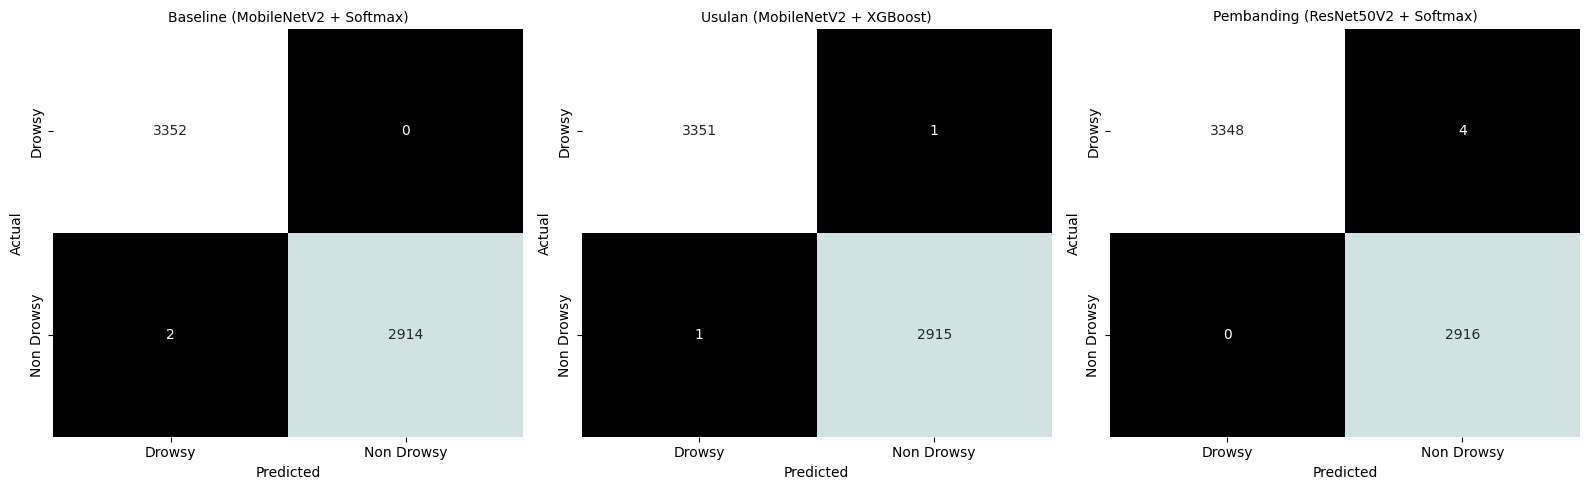

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, metrics) in zip(axes, results_summary.items()):
    sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt='d', cmap='bone',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


# 🔗 Kesimpulan
*(Isi bagian ini berdasarkan angka aktual hasil run di atas — kerangka analisis yang bisa dipakai:)*

- Bandingkan apakah **Usulan (MobileNetV2 + XGBoost)** mendekati atau melampaui performa **Baseline** dan **Pembanding**
  meskipun tidak melakukan fine-tuning pada backbone CNN.
- Bandingkan **training time**: Usulan seharusnya jauh lebih cepat karena backbone dibekukan dan hanya XGBoost yang dilatih
  di atas fitur yang sudah diekstraksi — ini mendukung argumen efisiensi dari pemisahan ekstraksi fitur dan pengambilan keputusan.
- Bandingkan **inference time per image** antar ketiga model untuk menilai kelayakan real-time.
- Diskusikan trade-off: apakah selisih akurasi (jika ada) sepadan dengan penghematan waktu training/komputasi.

**Catatan reproducibility:** dataset DDD berasal dari frame video yang diperlakukan sebagai citra 2D independen (bukan sequence),
sehingga tidak ada pemodelan temporal antar frame dalam pendekatan ini.
